In [1]:
# Brightway imports
import bw2data as bd
import brightway2 as bw

In [2]:
import lca_algebraic as agb

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [4]:
BW_PROJECT = 'metallican_new' # insert your project name here
bd.projects.set_current(BW_PROJECT)
EI_DB = 'ecoinvent-3.10-cutoff' # name of ecoinvent database in your project
metallican_db = 'metallican_lci_ei_copy'

In [5]:
# We use a separate DB for defining our foreground model / activities
# Choose any name
USER_DB = "foreground"
# Create and reset the user (foreground) database
agb.resetDb(USER_DB)

agb.setForeground(USER_DB)
# Reset the definition of all parameters
agb.resetParams()

# This is better to cleanup the whole foreground model each time, and redefine it in the notebook (or a python file)
# instead of relying on a state or previous run.
# Any persistent state is prone to errors.
#agb.resetDb(USER_DB)


[WARNING] Db foreground was here. Reseting it


In [6]:
agb.list_databases()

,backend,nb_activities,type
name,,,
biosphere3,sqlite,4362,biosphere
ecoinvent-3.10-cutoff,sqlite,23523,background
biosphere3_spatialized_flows,sqlite,110559,biosphere
ecoinvent-3.10-cutoff regionalized,sqlite,23523,background
Regioinvent,sqlite,228071,background
metallican_lci_ri,sqlite,51,background
metallican_lci_ei,sqlite,51,background
metallican_bgf_tech,sqlite,45,background
metallican_bgf_bio,sqlite,45,background


In [7]:
agb.list_parameters()

# A few details on lca-algebraic

## Search for activities

* Activities related to biosphere with biosphere with `agb.findBioAct`
* Activities related to biosphere with technosphere with `agb.findTechAct`
* Activities with `agb.findActivity`

## Distribution types

**lca_algebraic** supports seven distribution types:
- Fixed, not considered as a variable input for MC simulation
- Uniform distribution between min and max
- Triangle distribution between min and max (set to zero probability), with highest probability at default value
- Normal distribution, centered on default value (mean), with deviation of std and truncated between min and max
- Log-normal distribution, centered on default value (mean), with deviation of std, not truncated
- Beta distribution with extra params a and b, using default value as ‘loc’ (0 of beta distribution) and std as ‘scale’ (1 of beta distribution)
- Statistic weight

## Parameters types

**lca_algebraic** can define 3 types of parameters :
* Float parameter, with `newFloatParam(...)`. The user should provide its name, unit and statistical distribution.
* Bool parameter (e.g. 0 or 1), with `newBoolParam(...)`
* Enum parameter which represent a set of mutually exclusive choices, that corresponds to the definition of several boolean parameters with newEnumParam(...) > for example, for an electricity mix, we have to choose one mix among others
|


## Create, modify or switch activities

* Create a new activity with `agb.newActivity()`
* Copy and modified an activity with `agb.copyActivity()`
    * Change the value of a flow (with another number of mathematic formula) with `.updateExchanges`()
    * Change a flow by another flow with `.updateExchanges`()
    * Add a new flow with `.addExchanges`()
    * Delete an existing flow with `.updateExchanges`()
* Switch activity with `newSwitchAct`(), acting like a switch between several possibilities

# Search for LCIs

In [8]:
# For doré
rainy_river_dore = agb.findActivity(
                            name='Open-pit and underground mining and beneficiation at Rainy River',
                             loc='CA-ON',
                             db_name=metallican_db,
                             )

rainy_river_dore_2 = agb.copyActivity(
    USER_DB, # The copy of a background activity is done in our own DB, so that we can safely update it
    rainy_river_dore, # Initial activity : won't be altered
    "Rainy River 2") # New name

In [9]:
# For Cu
copper_mountain_cu = agb.findActivity(
                            name='Open-pit mining and beneficiation at Copper Mountain',
                             loc='CA-BC',
                             db_name=metallican_db,
                             )

copper_mountain_cu_2 = agb.copyActivity(
    USER_DB, # The copy of a background activity is done in our own DB, so that we can safely update it
    copper_mountain_cu, # Initial activity : won't be altered
    "Copper mountain 2") # New name

In [ ]:
#agb.printAct(copper_moutain_cu, copper_moutain_cu_2)

In [9]:
# For Ni
thompson_ni = agb.findActivity(
                            name='Open-pit and underground mining and beneficiation at Thompson (T-1 and T-3)',
                             loc='CA-MB',
                             db_name=metallican_db,
                             )

thompson_ni_2 = agb.copyActivity(
    USER_DB, # The copy of a background activity is done in our own DB, so that we can safely update it
    thompson_ni, # Initial activity : won't be altered
    "Thompson Ni 2") # New name

In [10]:
# For U
key_lake_u = agb.findActivity(
                            name='Underground mining and beneficiation at Key Lake + McArthur River',
                             loc='CA-SK',
                             db_name=metallican_db,
                             )

key_lake_u_2 = agb.copyActivity(
    USER_DB, # The copy of a background activity is done in our own DB, so that we can safely update it
    key_lake_u, # Initial activity : won't be altered
    "Key Lake U 2") # New name


# Select LCIA methods

In [10]:
LCIA_method = 'IMPACT World+ Midpoint 2.1_regionalized for ecoinvent v3.10'
biodiversity = 'Land transformation, biodiversity'
climate_change = 'Climate change, short term'

In [11]:
list_impact_categories=agb.findMethods("",LCIA_method)

In [12]:
# List of impacts to consider
biodiv_impact = agb.findMethods('Land transformation, biodiversity', LCIA_method)
biodiv_impact

[('IMPACT World+ Midpoint 2.1_regionalized for ecoinvent v3.10',
  'Midpoint',
  'Land transformation, biodiversity')]

In [13]:
climate_impact = agb.findMethods('Climate change, short term', LCIA_method)
climate_impact

[('IMPACT World+ Midpoint 2.1_regionalized for ecoinvent v3.10',
  'Midpoint',
  'Climate change, short term')]

# Parametrize inventory

In [14]:
# Flow land transformation (m²/kg de produit)
#LT_per_FU = A / (Q_ref * N)

# Flow CO2 LULUC (kgCO2/kg de produit)
#CO2_LULUC_per_FU = (A * delta_C * alpha) / (Q_ref * N)

# Exemple pour un site avec :
# A = aire transformée (m²)
# Q_ref = production annuelle (kg/an)
# delta_C = variation de stock carbone (kgC/m²)
# alpha = 44/12 (conversion C -> CO2)

## Float parameters

In [15]:
amortization_period = agb.newFloatParam(
    name='amortization_period',
    default=20,
    #std=2,
    min=1,
    max=100,
    unit='year',
    distrib=agb.DistributionType.TRIANGLE,
    description="Amortization period 0-100 years with a default value of 20 years",
    label="amortization period for land transformation",
    dbname=USER_DB,
    #save=False #By default, new parameters are kept in memory but also persisted in the project (unless save=False)
)

In [16]:
print(type(amortization_period))

<class 'lca_algebraic.params.ParamDef'>


## Update the exchanges

In [17]:
rainy_river_dore_2.updateExchanges({
    'Transformation, from forest, secondary (non-use)':
        141.49 * 20 / amortization_period,

    'Transformation, to mineral extraction site':
        141.49 * 20 / amortization_period,

     'Carbon dioxide, from soil or biomass stock':
        2334.6 * 20 / amortization_period

})

In [18]:
copper_mountain_cu_2.updateExchanges({
    'Transformation, from forest, secondary (non-use)':
        0.01042 * 20 / amortization_period,

    'Transformation, to mineral extraction site':
        0.01042 * 20 / amortization_period,

     'Carbon dioxide, from soil or biomass stock':
        0.19485 * 20 / amortization_period

})

In [ ]:
thompson_ni_2.updateExchanges({
    'Transformation, from forest, secondary (non-use)':
        0.010597 * 20 / amortization_period,

    'Transformation, to mineral extraction site':
        0.010597 * 20 / amortization_period,

     'Carbon dioxide, from soil or biomass stock':
        0.12434 * 20 / amortization_period

})

In [ ]:
# Pour voir la différence entre l'activité originale et la parametrized
agb.printAct(copper_mountain_cu, copper_mountain_cu_2)

In [ ]:
agb.list_parameters()

In [ ]:
# Inspecter les exchanges de land transformation
# for exc in copper_moutain_cu_2.exchanges():
#     name = exc.input.get('name', '')
#     if 'Transformation' in name or 'occupation' in name.lower():
#         print('---')
#         print('Name    :', name)
#         print('Amount  :', exc.get('amount'))
#         print('Formula :', exc.get('formula', 'PAS DE FORMULE ⚠️'))

In [ ]:
# Étape 3 — corriger amount (comportement inévitable de lca_algebraic)
# for exc in copper_moutain_cu_2.exchanges():
#     if 'Transformation' in exc.input.get('name', ''):
#         exc['amount'] = 0.01042  # restaurer la valeur par défaut N=20
#         exc.save()
# copper_moutain_cu_2.save()

# Run LCA calculation with different amortization periods

In [20]:
# Étape 1 — calcul
df_rainy_river_biodiv = compute_sensitivity_amortization(
    activity=rainy_river_dore_2,
    impacts=biodiv_impact,
    N_default=20,
)

df_rainy_river_climate = compute_sensitivity_amortization(
    activity=rainy_river_dore_2,
    impacts=climate_impact,
    N_default=20,
)

[INFO] Db changed recently, clearing cache expr
[INFO] Db changed recently, clearing cache lcia
[INFO] Db changed recently, clearing cache expr


N=   1 yr → 2987.497027
N=   5 yr → 606.074337
N=  10 yr → 308.396501
N=  15 yr → 209.170556
N=  20 yr → 159.557583
N=  25 yr → 129.789799
N=  30 yr → 109.944610
N=  35 yr → 95.769475
N=  40 yr → 85.138124
N=  45 yr → 76.869295
N=  50 yr → 70.254232
N=  55 yr → 64.841908
N=  60 yr → 60.331638
N=  65 yr → 56.515255
N=  70 yr → 53.244070
N=  75 yr → 50.409043
N=  80 yr → 47.928395
N=  85 yr → 45.739587
N=  90 yr → 43.793980
N=  95 yr → 42.053174
N= 100 yr → 40.486449

          Midpoint - Land transformation, biodiversity[m2 arable land eq]
N_years                                                                 
1                                                  2,987.5              
5                                                  606.074              
10                                                 308.397              
15                                                 209.171              
20                                                 159.558              
25               

In [21]:
# Étape 1 — calcul
df_copper_mountain_biodiv = compute_sensitivity_amortization(
    activity=copper_mountain_cu_2,
    impacts=biodiv_impact,
    N_default=20,
)

df_copper_mountain_climate = compute_sensitivity_amortization(
    activity=copper_mountain_cu_2,
    impacts=climate_impact,
    N_default=20,
)

[INFO] Db changed recently, clearing cache lcia
[INFO] Db changed recently, clearing cache expr


N=   1 yr → 0.219944
N=   5 yr → 0.044565
N=  10 yr → 0.022643
N=  15 yr → 0.015335
N=  20 yr → 0.011681
N=  25 yr → 0.009489
N=  30 yr → 0.008028
N=  35 yr → 0.006984
N=  40 yr → 0.006201
N=  45 yr → 0.005592
N=  50 yr → 0.005105
N=  55 yr → 0.004706
N=  60 yr → 0.004374
N=  65 yr → 0.004093
N=  70 yr → 0.003852
N=  75 yr → 0.003643
N=  80 yr → 0.003460
N=  85 yr → 0.003299
N=  90 yr → 0.003156
N=  95 yr → 0.003028
N= 100 yr → 0.002912

          Midpoint - Land transformation, biodiversity[m2 arable land eq]
N_years                                                                 
1                                                 0.219944              
5                                                 0.044565              
10                                                0.022643              
15                                                0.015335              
20                                                0.011681              
25                                            

In [22]:
import pandas as pd

In [23]:
output_path = "results\Sensitivity.xlsx"

with pd.ExcelWriter(output_path, engine="openpyxl") as writer:
    df_rainy_river_biodiv.to_excel(writer, sheet_name="df_rainy_river_biodiv", index=False)
    df_rainy_river_climate.to_excel(writer, sheet_name="df_rainy_river_climate", index=False)
    df_copper_mountain_biodiv.to_excel(writer, sheet_name="df_copper_mountain_biodiv", index=False)
    df_copper_mountain_climate.to_excel(writer, sheet_name="df_copper_mountain_climate", index=False)

Saved: results\Sensitivity\rainy_river_sensitivity_biodiv.pdf
Saved: results\Sensitivity\rainy_river_sensitivity_biodiv.png


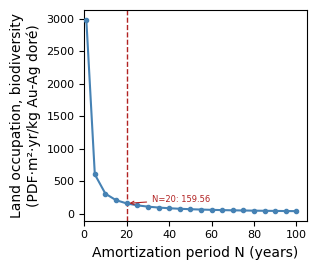

Saved: results\Sensitivity\rainy_river_sensitivity_climate.pdf
Saved: results\Sensitivity\rainy_river_sensitivity_climate.png


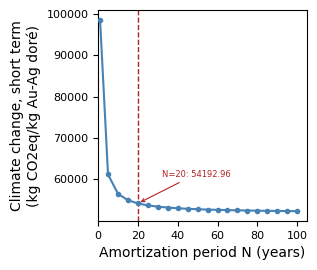

In [24]:
fig_df_rainy_river_biodiv = plot_sensitivity_amortization(
    df_sensitivity=df_rainy_river_biodiv,
    N_default=20,
    ylabel="Land occupation, biodiversity\n(PDF·m²·yr/kg Au-Ag doré)",
    title='',
    output_name=r"results\Sensitivity\rainy_river_sensitivity_biodiv",
)

fig_df_rainy_river_climate = plot_sensitivity_amortization(
    df_sensitivity=df_rainy_river_climate,
    N_default=20,
    ylabel="Climate change, short term\n(kg CO2eq/kg Au-Ag doré)",
    title='',
    output_name=r"results\Sensitivity\rainy_river_sensitivity_climate",
)

Saved: results\Sensitivity\copper_mountain_sensitivity_biodiv.pdf
Saved: results\Sensitivity\copper_mountain_sensitivity_biodiv.png


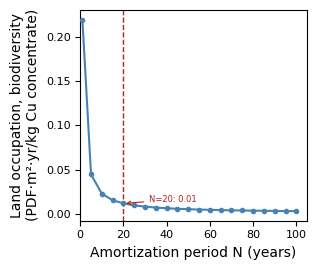

Saved: results\Sensitivity\copper_mountain_sensitivity_climate.pdf
Saved: results\Sensitivity\copper_mountain_sensitivity_climate.png


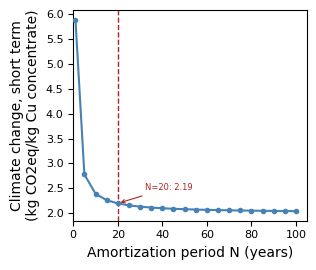

In [25]:
fig_df_copper_mountain_biodiv = plot_sensitivity_amortization(
    df_sensitivity=df_copper_mountain_biodiv,
    N_default=20,
    ylabel="Land occupation, biodiversity\n(PDF·m²·yr/kg Cu concentrate)",
    title='',
    output_name=r"results\Sensitivity\copper_mountain_sensitivity_biodiv",
)

fig_df_copper_mountain_climate = plot_sensitivity_amortization(
    df_sensitivity=df_copper_mountain_climate,
    N_default=20,
    ylabel="Climate change, short term\n(kg CO2eq/kg Cu concentrate)",
    title='',
    output_name=r"results\Sensitivity\copper_mountain_sensitivity_climate",
)

In [19]:
def compute_sensitivity_amortization(
    activity,
    impacts,
    N_values=None,
    N_default=20,
    functional_unit=1,
):
    """
    Compute LCA impacts for a range of amortization periods.

    Parameters
    ----------
    activity : brightway2 Activity
        Activity with amortization_period parameter in exchanges.
    impacts : list
        List of LCIA methods (tuples).
    N_values : list, optional
        Amortization periods to test.
        Default: [1, 5, 10, ..., 100]
    N_default : int, optional
        Reference amortization period. Default: 20 (UNEP-SETAC).
    functional_unit : float, optional
        Functional unit. Default: 1.

    Returns
    -------
    df : pd.DataFrame
        Results with N_years as index.
    """
    import pandas as pd
    import lca_algebraic as agb

    if N_values is None:
        N_values = [1] + list(range(5, 101, 5))
    if N_default not in N_values:
        N_values = sorted(N_values + [N_default])

    results = []
    for N in N_values:
        result = agb.compute_impacts(
            activity,
            impacts,
            functional_unit=functional_unit,
            amortization_period=N
        )
        row = {'N_years': N}
        for col in result.columns:
            row[col] = float(result[col].iloc[0])
        results.append(row)
        print(f"N={N:4d} yr → {list(row.values())[1]:.6f}")

    df = pd.DataFrame(results).set_index('N_years')
    print("\n", df.round(6))
    return df


def plot_sensitivity_amortization(
    df_sensitivity,
    N_default=20,
    ylabel="Potential damage score",
    title="Sensitivity of land transformation impacts\nto amortization period",
    output_name="sensitivity_amortization",
    color='steelblue',
):
    """
    Plot sensitivity of LCA impacts to amortization period N.

    Parameters
    ----------
    df_sensitivity : pd.DataFrame
        Output of compute_sensitivity_amortization().
    N_default : int, optional
        Reference N for annotation. Default: 20.
    ylabel : str, optional
        Y-axis label.
    title : str, optional
        Figure title.
    output_name : str, optional
        Base name for saved files (no extension).
    color : str, optional
        Line color. Default: 'steelblue'.

    Returns
    -------
    fig : matplotlib Figure
    """
    import matplotlib.pyplot as plt

    # ES&T single-column width = 3.27 in, double = 6.77 in
    fig, ax = plt.subplots(figsize=(3.27, 2.8))

    for col in df_sensitivity.columns:
        ax.plot(
            df_sensitivity.index,
            df_sensitivity[col],
            color=color,
            linewidth=1.5,
            marker='o',
            markersize=3,
            label=col,
            zorder=3,
        )

    # Reference line
    ax.axvline(
        x=N_default,
        color='firebrick',
        linestyle='--',
        linewidth=1.0,
        #label=f'Default N={N_default} yr (UNEP-SETAC)',
        zorder=2,
    )

    # Annotation
    if N_default in df_sensitivity.index:
        default_val = df_sensitivity.loc[N_default].iloc[0]
        ax.annotate(
            f'N={N_default}: {default_val:.2f}',
            xy=(N_default, default_val),
            xytext=(N_default + 12, default_val * 1.12),
            arrowprops=dict(
                arrowstyle='->',
                color='firebrick',
                lw=0.8,
            ),
            fontsize=6,
            color='firebrick',
        )

    ax.set_xlabel('Amortization period N (years)', fontsize=10)
    ax.set_ylabel(ylabel, fontsize=10)
    ax.set_title(title, fontsize=7, fontweight='bold')
    ax.tick_params(labelsize=8)
    #ax.legend(fontsize=5.5, framealpha=0.8)
    #ax.grid(True, alpha=0.25, linewidth=0.5)
    ax.set_xlim(left=0)
    #ax.set_ylim(bottom=0)

    plt.tight_layout()

    # Save
    fig.savefig(
        f"{output_name}.pdf",
        dpi=600,
        bbox_inches='tight',
        format='pdf',
    )
    fig.savefig(
        f"{output_name}.png",
        dpi=600,
        bbox_inches='tight',
    )
    print(f"Saved: {output_name}.pdf")
    print(f"Saved: {output_name}.png")

    plt.show()
    return fig

In [ ]:
agb.compute_impacts(
    copper_moutain_cu_2,
    impacts,
    functional_unit=1,
    amortization_period=100
)

In [ ]:
agb.compute_impacts(
    copper_moutain_cu_2,
    impacts,
    functional_unit=1,
    amortization_period=1
)

In [ ]:
agb.compute_impacts(
    copper_moutain_cu_2,
    impacts,
    functional_unit=1,
    amortization_period=100
)

In [ ]:
for N in [1, 10, 20, 40, 100]:
    result = agb.compute_impacts(
        copper_moutain_cu_2,
        impacts,
        functional_unit=1,
        amortization_period=N
    )
    val = float(result.iloc[0, 0])
    print(f"N={N:3d} → {val:.6f}")

In [ ]:
# 1. Vérifier dans quelle base est l'activité
print("DB de copper_mountain_cu_2:", copper_moutain_cu_2['database'])

# 2. Vérifier dans quelle base est le paramètre
print("DB du paramètre:", amortization_period.dbname)

In [ ]:
import bw2calc as bc
import pandas as pd

old_LT = 0.010419850699685
N_values = [1, 10, 20, 40, 100]
results = []

for N in N_values:

    # Mettre à jour amount directement
    for exc in copper_moutain_cu_2.exchanges():
        if 'Transformation' in exc.input.get('name', ''):
            exc['amount'] = old_LT * 20 / N
            exc.save()
    copper_moutain_cu_2.save()

    # Calculer
    row = {'N_years': N}
    for method in impacts:
        lca = bc.LCA({copper_moutain_cu_2: 1}, method)
        lca.lci()
        lca.lcia()
        row[method[-1]] = lca.score
    results.append(row)
    print(f"N={N:3d} → {row}")

# Restaurer N=20
for exc in copper_moutain_cu_2.exchanges():
    if 'Transformation' in exc.input.get('name', ''):
        exc['amount'] = old_LT
        exc.save()
copper_moutain_cu_2.save()

df = pd.DataFrame(results).set_index('N_years')
print(df)

In [ ]:
agb.oat_matrix(
    copper_moutain_cu,
    impacts,
    functional_unit=1,
    n=10
)

In [ ]:
agb.oat_dashboard(
    copper_moutain_cu,
    impacts,
    functional_unit=1,

    # Optionnal layout parameters
    figspace=(0.5,0.5),
    figsize=(15, 15),
    sharex=True)



In [ ]:
##### Alternatively, graphs can be shown horizontally, together with a box of statistical outcomes
agb.distrib(
    copper_moutain_cu, impacts,
    functional_unit=1,

    # Optionnal layout parameters
    height=7, width=15,
    nb_cols=2,
    percentiles=[5, 95])

In [ ]:
# Exemple of a enum parameter, i.e. that can take discrete values
mining_electricity_switch = agb.newEnumParam(
    name='mining_electricity_switch',
    default='dieselgenerator',
    values=['dieselgenerator',
            'grid'],
    description="Choice of electricity source for mining",
    dbname=USER_DB)


elec_mix_country=agb.newEnumParam(
    name="electrical mix",        # label
    description="region chosen for the electricity mix", # Long description
    values =[                       # Statistic weight of each option that fits with the market
        "Alberta",
        "Quebec"
    ],
    default="Quebec",
    dbname=USER_DB)

In [ ]:
# Then we search for activities to associate to the discrete values
diesel_generator = agb.findActivity('market for diesel', loc='RoW', db_name=EI_DB)
elec_grid = agb.findActivity('market group for electricity, high voltage', loc='CA', db_name=EI_DB)

# Finally we create a new switch act
mining_elec_mix = agb.newSwitchAct(USER_DB, 'mining_elec_mix', # Name
    mining_electricity_switch, # Switch parameter
    {
        'dieselgenerator' : diesel_generator, # in MJ
        'grid' : (elec_grid, 1/3.6)  # in MJ (convert from kWh)
    })

In [ ]:
# Then we update the exchange of the mining activity with the new switch act
cu_mining_benef.deleteExchanges("market for electricity, low voltage", loc='CA', db_name=EI_DB)
cu_mining_benef.addExchanges(
    {mining_elec_mix: 1 # we can also parametrize the amount of the exchanges
    }
)

# Calculation of scenarios

In [ ]:
test = agb.compute_impacts(act, methods, og_cu_world=0.5, mining_electricity_switch='grid', elec_mix_country='Alberta')

In [ ]:
params = {'electrical mix': "Alberta"}

In [ ]:
ag